## **MDQ Project**
  - An end-to-end AI solution for discovering hidden commercial activity among physical persons using transaction analytics, clustering, and predictive modeling.

  Team name: The Ace of tech

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

In [3]:
business = pd.read_parquet("business_cards_MDQ.parquet")
consumer = pd.read_parquet("consumer_cards_MDQ.parquet")
merchants = pd.read_parquet("merchants_reference.parquet")

## EDA part

In [4]:
# размеры датасетов
print("Business shape:", business.shape)
print("Consumer shape:", consumer.shape)
print("Merchants shape:", merchants.shape)

Business shape: (2997593, 12)
Consumer shape: (9832487, 12)
Merchants shape: (2165, 5)


In [5]:
# просматриваем колонки и типы данных
print("Business columns:")
print(business.columns.tolist())
print(business.dtypes)
print(business.info())
print("\n")  # добавляем пустую строку для разделения вывода

print("\nConsumer columns:")
print(consumer.columns.tolist())
print(consumer.dtypes)
print(consumer.info())


print("\nMerchants columns:")
print(merchants.columns.tolist())
print(merchants.dtypes)
print(merchants.info())

Business columns:
['transaction_date', 'transaction_timestamp', 'transaction_amount_kzt', 'mcc', 'merchant_id', 'channel', 'bank_name', 'country', 'card_number', 'card_tier', 'tokenized', 'is_recurring']
transaction_date                  object
transaction_timestamp     datetime64[ms]
transaction_amount_kzt             int64
mcc                               object
merchant_id                       object
channel                           object
bank_name                         object
country                           object
card_number                       object
card_tier                         object
tokenized                           bool
is_recurring                        bool
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2997593 entries, 0 to 2997592
Data columns (total 12 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   transaction_date        object        
 1   transaction_timestamp   datetime64[ms]
 

#### Смотрим первые колонки\данные

In [6]:
business.head()


,transaction_date,transaction_timestamp,transaction_amount_kzt,mcc,merchant_id,channel,bank_name,country,card_number,card_tier,tokenized,is_recurring
0,2025-10-01,2025-10-01 00:00:00,180976,7372,MER_000007,online,Kaspi,US,5228592291438845,Business,False,True
1,2025-10-01,2025-10-01 00:00:00,153206,7372,MER_000006,online,Home Credit Bank,US,5201495142193372,Business,False,True
2,2025-10-01,2025-10-01 00:00:00,197106,7372,MER_000007,online,Home Credit Bank,US,5201492177677288,Business,False,True
3,2025-10-01,2025-10-01 00:01:00,189598,7372,MER_000008,online,Kaspi,US,5176513443697635,Business,False,True
4,2025-10-01,2025-10-01 00:03:00,700571,7311,MER_000003,online,Halyk,Russia,5100611967455520,Business,False,True


In [7]:
consumer.head()

,transaction_date,transaction_timestamp,transaction_amount_kzt,mcc,merchant_id,channel,bank_name,country,card_number,card_tier,tokenized,is_recurring
0,2025-10-01,2025-10-01 00:04:00,4788,4814,MER_000064,online,Alatau City Bank,Kazakhstan,5263907968824596,Standard,False,True
1,2025-10-01,2025-10-01 00:10:00,5240,4814,MER_000063,online,Bank RBK,Kazakhstan,5119023663984986,Standard,False,True
2,2025-10-01,2025-10-01 00:12:00,4576,4814,MER_000066,online,Kaspi,Kazakhstan,5228590878155154,Standard,False,True
3,2025-10-01,2025-10-01 00:37:00,6078,4814,MER_000063,online,Home Credit Bank,Kazakhstan,5338472125333693,Standard,False,True
4,2025-10-01,2025-10-01 00:37:00,6042,4814,MER_000065,online,Kaspi,Kazakhstan,5531514712394557,Affluent,False,True


In [8]:
merchants.head()

,merchant_id,merchant_name,mcc,merchant_country,recurring_capable
0,MER_000000,Google Ads,7311,Ireland,True
1,MER_000001,Meta Ads,7311,Ireland,True
2,MER_000002,TikTok Ads,7311,Singapore,True
3,MER_000003,Yandex Direct,7311,Russia,True
4,MER_000004,LinkedIn Ads,7311,Ireland,True


In [9]:
business.isna().sum().sort_values(ascending=False) # проверяем пропуски в бизнес датасете

transaction_date          0
transaction_timestamp     0
transaction_amount_kzt    0
mcc                       0
merchant_id               0
channel                   0
bank_name                 0
country                   0
card_number               0
card_tier                 0
tokenized                 0
is_recurring              0
dtype: int64

In [10]:
consumer.isna().sum().sort_values(ascending=False) # проверяем пропуски в потребительском датасете

transaction_date          0
transaction_timestamp     0
transaction_amount_kzt    0
mcc                       0
merchant_id               0
channel                   0
bank_name                 0
country                   0
card_number               0
card_tier                 0
tokenized                 0
is_recurring              0
dtype: int64

In [11]:
merchants.isna().sum().sort_values(ascending=False) # проверяем пропуски в датасете с информацией о торговых точках

merchant_id          0
merchant_name        0
mcc                  0
merchant_country     0
recurring_capable    0
dtype: int64

In [12]:
# проверяем дупликаты в бизнес датасете
print("Business duplicates:", business.duplicated().sum())

Business duplicates: 0


In [13]:
# дупликаты в потребительском датасете
print("Consumer duplicates:", consumer.duplicated().sum())

Consumer duplicates: 0


In [62]:
# дупликаты в потребительском датасете
print("Consumer duplicates:", consumer.duplicated().sum())

Consumer duplicates: 0


In [ ]:
# добавляем таргет
business["target"] = 1 # business behavior
consumer["target"] = 0 # consumer behavior

In [ ]:
# Объединяем датасеты (business и consumer) для дальнейшего анализа
data = pd.concat([business, consumer], ignore_index=True)

print(data.shape)
data.head()

(12830080, 13)


,transaction_date,transaction_timestamp,transaction_amount_kzt,mcc,merchant_id,channel,bank_name,country,card_number,card_tier,tokenized,is_recurring,target
0,2025-10-01,2025-10-01 00:00:00,180976,7372,MER_000007,online,Kaspi,US,5228592291438845,Business,False,True,1
1,2025-10-01,2025-10-01 00:00:00,153206,7372,MER_000006,online,Home Credit Bank,US,5201495142193372,Business,False,True,1
2,2025-10-01,2025-10-01 00:00:00,197106,7372,MER_000007,online,Home Credit Bank,US,5201492177677288,Business,False,True,1
3,2025-10-01,2025-10-01 00:01:00,189598,7372,MER_000008,online,Kaspi,US,5176513443697635,Business,False,True,1
4,2025-10-01,2025-10-01 00:03:00,700571,7311,MER_000003,online,Halyk,Russia,5100611967455520,Business,False,True,1


In [ ]:
# проверяем баланс классов
print("Class distribution:")
print(data["target"].value_counts())
data["target"].value_counts(normalize=True) * 100

Class distribution:
target
0    9832487
1    2997593
Name: count, dtype: int64


target
0    76.63621
1    23.36379
Name: proportion, dtype: float64

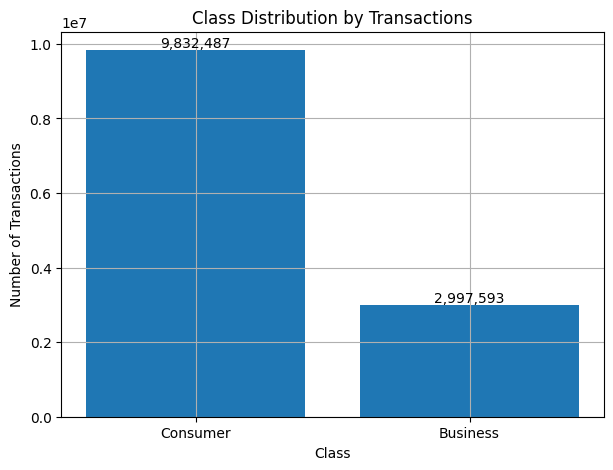

In [ ]:
class_counts = data["target"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(["Consumer", "Business"], class_counts.values)

plt.title("Class Distribution by Transactions")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")

for i, value in enumerate(class_counts.values):
    plt.text(i, value, f"{value:,}", ha="center", va="bottom")

plt.show()

#### **Class Distribution**

At the current stage, class distribution is calculated on the transaction level rather than the card level.

Current dataset balance:
- Consumer transactions: 76.6%
- Business transactions: 23.4%

Further during data preprocessing, aggregation by `card_number` will be performed, transforming the dataset into:
    
1 row = 1 card

This approach is more appropriate for behavioral modeling and helps reduce data leakage and overfitting.


This chart shows the class distribution at the transaction level. Consumer transactions dominate the dataset, while business transactions represent a smaller but still significant part of the data. Later, after aggregation, the balance will be recalculated at the card level.

In [ ]:
# проверяем есть ли merchant_id
print("Merchant ID in business dataset:", "merchant_id" in business.columns)
print("Merchant ID in consumer dataset:", "merchant_id" in consumer.columns)

Merchant ID in business dataset: True
Merchant ID in consumer dataset: True


In [ ]:
data = data.merge(
    merchants,
    on="merchant_id",
    how="left",
    suffixes=("", "_merchant")
)

print(data.shape)
data.head()

(12830080, 17)


,transaction_date,transaction_timestamp,transaction_amount_kzt,mcc,merchant_id,channel,bank_name,country,card_number,card_tier,tokenized,is_recurring,target,merchant_name,mcc_merchant,merchant_country,recurring_capable
0,2025-10-01,2025-10-01 00:00:00,180976,7372,MER_000007,online,Kaspi,US,5228592291438845,Business,False,True,1,Microsoft Azure,7372,US,True
1,2025-10-01,2025-10-01 00:00:00,153206,7372,MER_000006,online,Home Credit Bank,US,5201495142193372,Business,False,True,1,Amazon Web Services,7372,US,True
2,2025-10-01,2025-10-01 00:00:00,197106,7372,MER_000007,online,Home Credit Bank,US,5201492177677288,Business,False,True,1,Microsoft Azure,7372,US,True
3,2025-10-01,2025-10-01 00:01:00,189598,7372,MER_000008,online,Kaspi,US,5176513443697635,Business,False,True,1,Google Cloud,7372,US,True
4,2025-10-01,2025-10-01 00:03:00,700571,7311,MER_000003,online,Halyk,Russia,5100611967455520,Business,False,True,1,Yandex Direct,7311,Russia,True


#### **Merchant Reference Merge**

At this stage, an additional merge operation is performed between the transaction datasets and the `merchants_reference` table using the `merchant_id` column.

The purpose of this merge is to enrich raw transaction data with additional merchant-related business information that is not directly available in the original transaction datasets.

The `merchant_id` field serves as a unique identifier for merchants and allows linking each transaction with its corresponding merchant attributes.

After the merge, the dataset contains additional information such as:
- Merchant Category Code (MCC)
- Merchant country
- Merchant category
- Recurring payment capability
- Additional merchant behavioral attributes

This step is critically important for further feature engineering and behavioral analysis because raw transaction data alone does not provide sufficient contextual information about merchant behavior.

By enriching the dataset with merchant metadata, it becomes possible to construct advanced behavioral features such as:
- merchant concentration
- MCC diversity
- foreign merchant activity
- recurring transaction share
- merchant category patterns
- online/offline behavioral indicators

These features are highly valuable for detecting hidden SME-like behavior among consumer cardholders, since commercial activity often demonstrates distinguishable transaction patterns compared to regular consumer behavior.

The merge operation is performed using a left join to preserve all original transaction records while appending available merchant information from the reference table.


In [ ]:
# базовое описание amount
data["transaction_amount_kzt"].describe()

count    1.283008e+07
mean     7.799094e+04
std      1.971753e+05
min      1.500000e+01
25%      5.028000e+03
50%      1.743100e+04
75%      6.875400e+04
max      4.079930e+07
Name: transaction_amount_kzt, dtype: float64

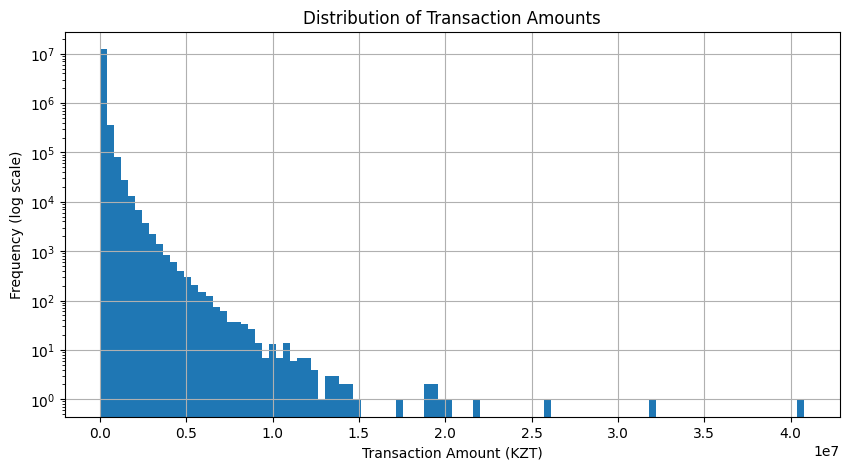

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(data["transaction_amount_kzt"], bins=100, log=True)

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount (KZT)")
plt.ylabel("Frequency (log scale)")

plt.show()

The distribution of transaction amounts is highly skewed. Most transactions are relatively small, while a small number of transactions have very large values. This is typical for financial data and indicates the presence of high-value operations or outliers.

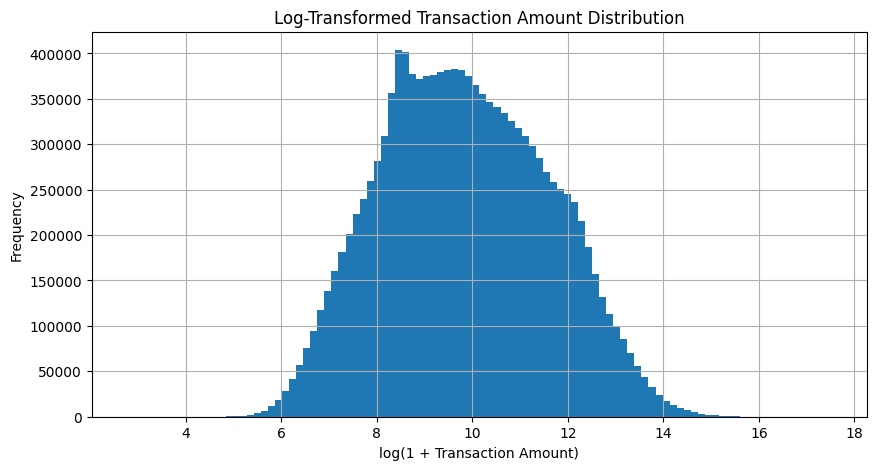

In [ ]:
data["log_amount"] = np.log1p(data["transaction_amount_kzt"])

plt.figure(figsize=(10, 5))

plt.hist(data["log_amount"], bins=100)

plt.title("Log-Transformed Transaction Amount Distribution")
plt.xlabel("log(1 + Transaction Amount)")
plt.ylabel("Frequency")

plt.show()

A log transformation makes the distribution easier to interpret by reducing the impact of extreme transaction values. This helps us better see the overall transaction behavior.

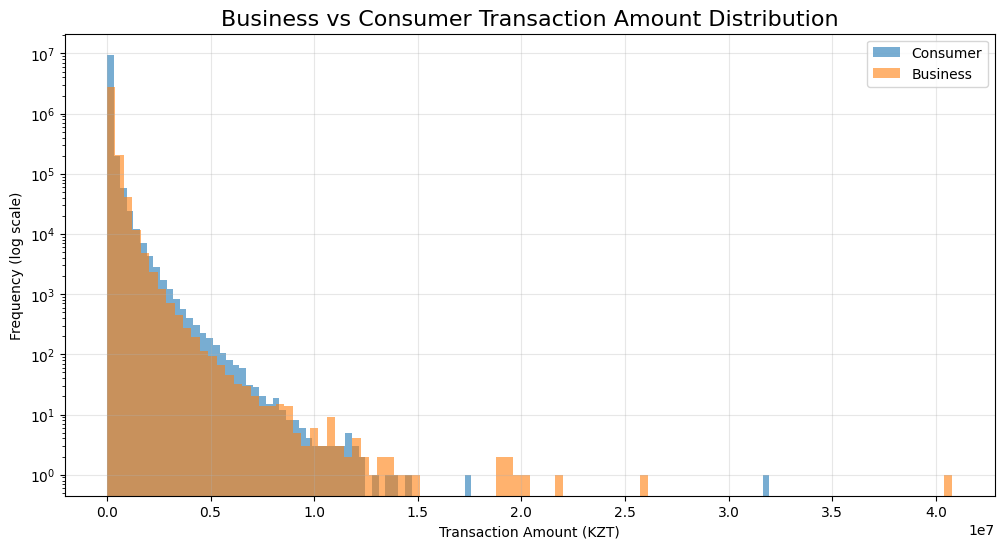

In [ ]:
plt.figure(figsize=(12,6))

plt.hist(
    data[data["target"] == 0]["transaction_amount_kzt"],
    bins=100,
    alpha=0.6,
    label="Consumer",
    log=True
)

plt.hist(
    data[data["target"] == 1]["transaction_amount_kzt"],
    bins=100,
    alpha=0.6,
    label="Business",
    log=True
)

plt.title("Business vs Consumer Transaction Amount Distribution", fontsize=16)

plt.xlabel("Transaction Amount (KZT)")
plt.ylabel("Frequency (log scale)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

<Figure size 1000x600 with 0 Axes>

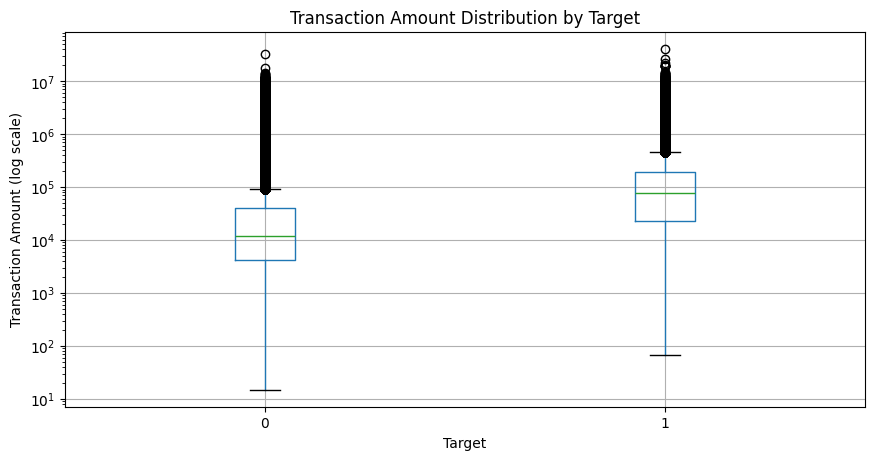

In [ ]:
plt.figure(figsize=(10,6))

data.boxplot(
    column="transaction_amount_kzt",
    by="target"
)

plt.yscale("log")

plt.title("Transaction Amount Distribution by Target")
plt.suptitle("")

plt.xlabel("Target")
plt.ylabel("Transaction Amount (log scale)")

plt.show()

The visualization confirms that business cardholders generally demonstrate higher transaction volumes and more extreme transaction values compared to regular consumer cardholders.

The heavy-tailed distribution further supports the assumption that transaction amount behavior may contain strong predictive signals for hidden SME detection.

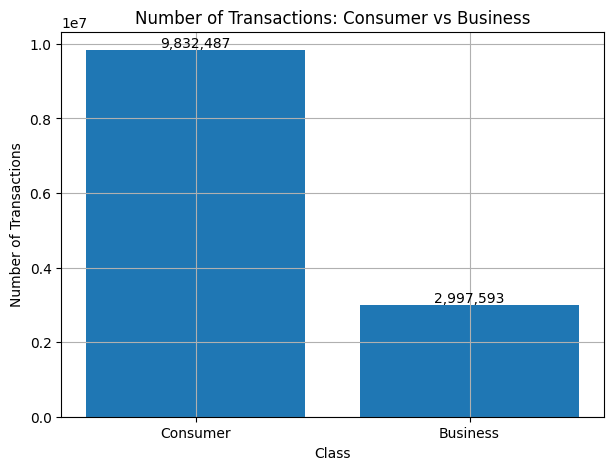

In [ ]:
tx_counts = data["target"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(["Consumer", "Business"], tx_counts.values)

plt.title("Number of Transactions: Consumer vs Business")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")

for i, value in enumerate(tx_counts.values):
    plt.text(i, value, f"{value:,}", ha="center", va="bottom")

plt.show()

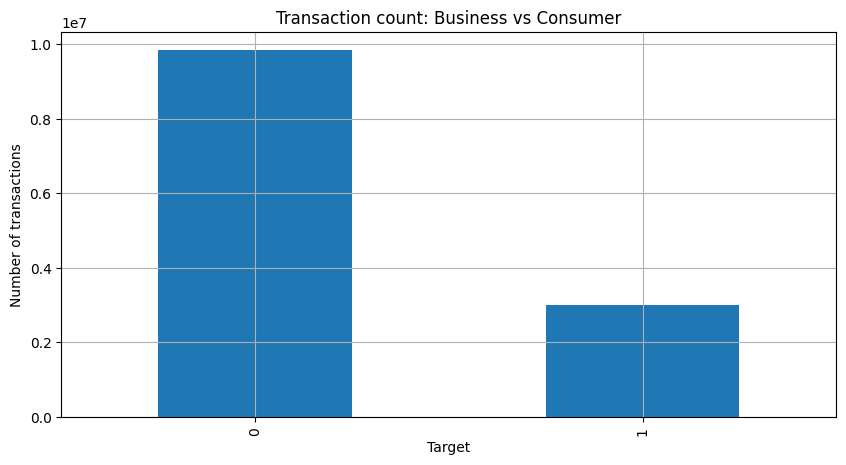

In [ ]:
# Сравнить количество транзакций
data["target"].value_counts().plot(kind="bar")
plt.title("Transaction count: Business vs Consumer")
plt.xlabel("Target")
plt.ylabel("Number of transactions")
plt.show()

In [ ]:
# Сравниваем суммы транзакций
data.groupby("target")["transaction_amount_kzt"].sum()
data.groupby("target")["transaction_amount_kzt"].mean()


target
0     54045.424791
1    156535.274681
Name: transaction_amount_kzt, dtype: float64

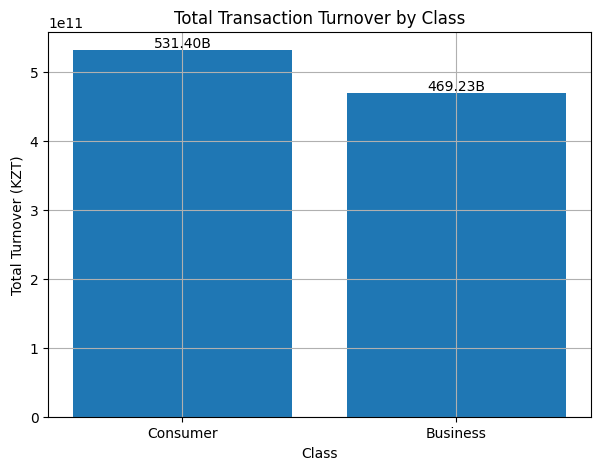

In [ ]:
turnover_by_class = data.groupby("target")["transaction_amount_kzt"].sum()

plt.figure(figsize=(7, 5))
plt.bar(["Consumer", "Business"], turnover_by_class.values)

plt.title("Total Transaction Turnover by Class")
plt.xlabel("Class")
plt.ylabel("Total Turnover (KZT)")

for i, value in enumerate(turnover_by_class.values):
    plt.text(i, value, f"{value/1e9:.2f}B", ha="center", va="bottom")

plt.show()

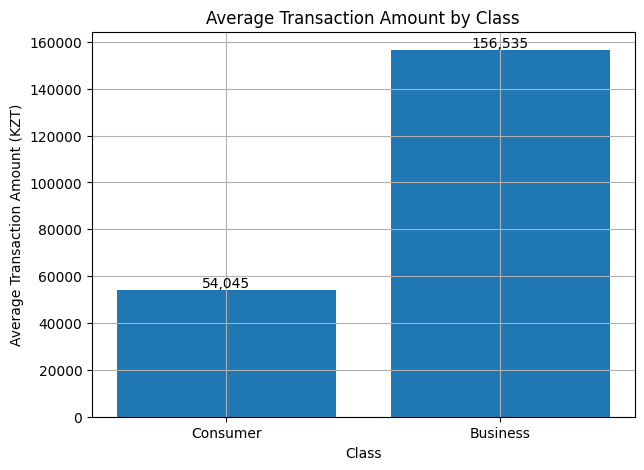

In [ ]:
mean_amount = data.groupby("target")["transaction_amount_kzt"].mean()

plt.figure(figsize=(7, 5))
plt.bar(["Consumer", "Business"], mean_amount.values)

plt.title("Average Transaction Amount by Class")
plt.xlabel("Class")
plt.ylabel("Average Transaction Amount (KZT)")

for i, value in enumerate(mean_amount.values):
    plt.text(i, value, f"{value:,.0f}", ha="center", va="bottom")

plt.show()

This chart shows total transaction turnover by class. Even if one class has fewer transactions, it may still represent a significant share of total transaction value, which is important for business impact analysis.

In [ ]:
# Проверяем card_number
data["card_number"].nunique()

105000

In [ ]:
data.groupby("target")["card_number"].nunique()

target
0    80000
1    25000
Name: card_number, dtype: int64

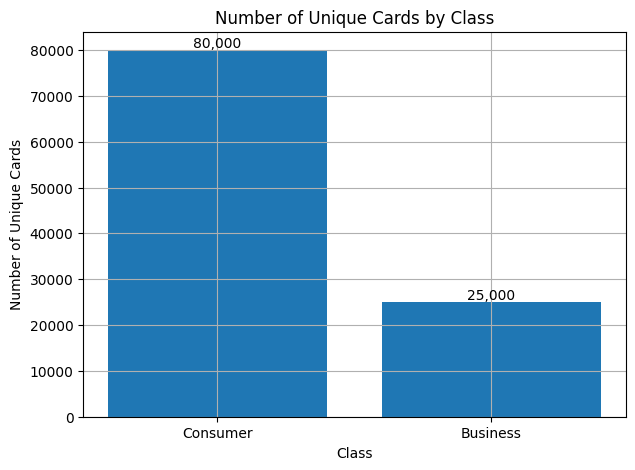

In [ ]:
cards_by_class = data.groupby("target")["card_number"].nunique()

plt.figure(figsize=(7, 5))
plt.bar(["Consumer", "Business"], cards_by_class.values)

plt.title("Number of Unique Cards by Class")
plt.xlabel("Class")
plt.ylabel("Number of Unique Cards")

for i, value in enumerate(cards_by_class.values):
    plt.text(i, value, f"{value:,}", ha="center", va="bottom")

plt.show()

This chart shows the number of unique cards in each class. This is important because the final model will be trained at the card level, not at the transaction level.

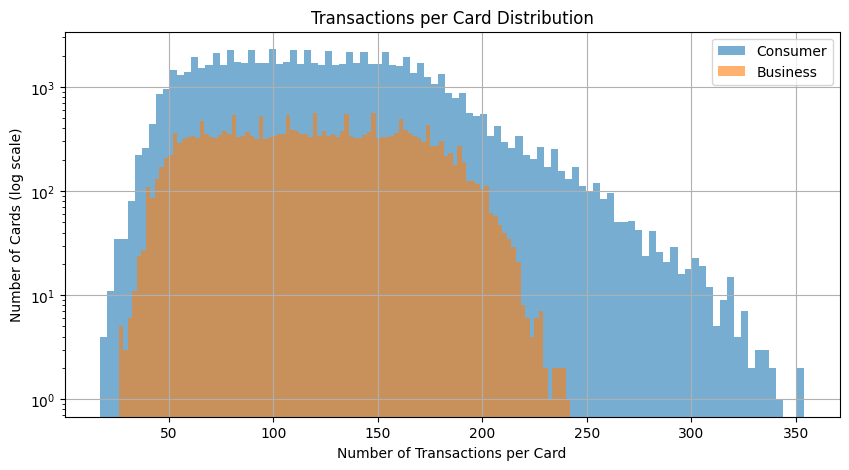

In [ ]:
tx_per_card = data.groupby(["target", "card_number"]).size().reset_index(name="tx_count")

plt.figure(figsize=(10, 5))

plt.hist(
    tx_per_card[tx_per_card["target"] == 0]["tx_count"],
    bins=100,
    alpha=0.6,
    label="Consumer",
    log=True
)

plt.hist(
    tx_per_card[tx_per_card["target"] == 1]["tx_count"],
    bins=100,
    alpha=0.6,
    label="Business",
    log=True
)

plt.title("Transactions per Card Distribution")
plt.xlabel("Number of Transactions per Card")
plt.ylabel("Number of Cards (log scale)")
plt.legend()

plt.show()

This chart shows how active cards are in terms of transaction frequency. Higher transaction frequency may indicate business-like behavior, especially when combined with turnover, recurring activity, and merchant concentration.

In [ ]:
# Посмотриваем merchant behavior
data.groupby("target")["merchant_id"].nunique()
data.groupby("target")["mcc"].nunique()

target
0    500
1    104
Name: mcc, dtype: int64

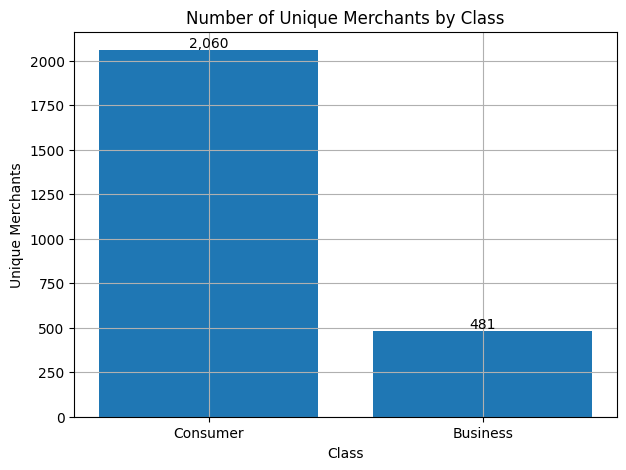

In [ ]:
unique_merchants = data.groupby("target")["merchant_id"].nunique()

plt.figure(figsize=(7, 5))
plt.bar(["Consumer", "Business"], unique_merchants.values)

plt.title("Number of Unique Merchants by Class")
plt.xlabel("Class")
plt.ylabel("Unique Merchants")

for i, value in enumerate(unique_merchants.values):
    plt.text(i, value, f"{value:,}", ha="center", va="bottom")

plt.show()

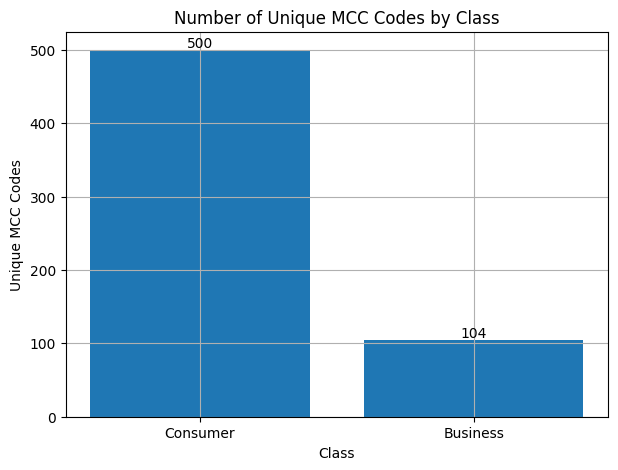

In [ ]:
unique_mcc = data.groupby("target")["mcc"].nunique()

plt.figure(figsize=(7, 5))
plt.bar(["Consumer", "Business"], unique_mcc.values)

plt.title("Number of Unique MCC Codes by Class")
plt.xlabel("Class")
plt.ylabel("Unique MCC Codes")

for i, value in enumerate(unique_mcc.values):
    plt.text(i, value, f"{value:,}", ha="center", va="bottom")

plt.show()

Merchant and MCC diversity help describe how broad or concentrated client activity is. Business-like clients may demonstrate specific merchant patterns or operate within business-related MCC categories.

In [ ]:
# top mcc
data["mcc"].value_counts().head(20)

mcc
4814    543149
7311    527642
5812    523170
4121    432892
5541    405949
4111    296963
7372    285946
5814    271376
7011    265768
4511    264033
4899    260750
5968    252624
5311    239311
5411    224191
5999    219868
4816    217785
5912    194054
5499    172674
5542    170271
5099    169824
Name: count, dtype: int64

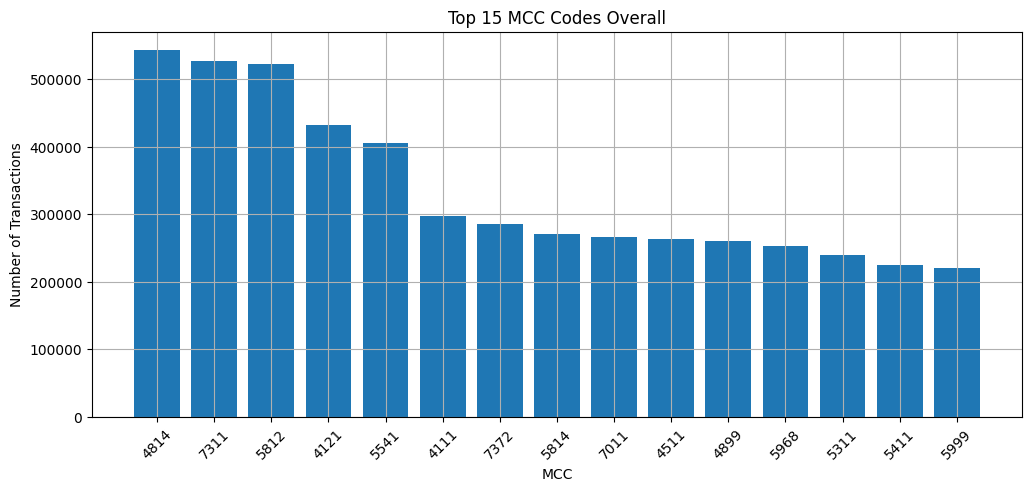

In [ ]:
top_mcc = data["mcc"].value_counts().head(15)

plt.figure(figsize=(12, 5))
plt.bar(top_mcc.index.astype(str), top_mcc.values)

plt.title("Top 15 MCC Codes Overall")
plt.xlabel("MCC")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.show()

In [ ]:
# business mcc
data[data["target"] == 1]["mcc"].value_counts().head(20)

mcc
7311    271527
7372    239687
5968    205593
4816    189791
7399    108963
7011     95045
4511     94627
5045     94044
7392     93823
4814     91669
4214     83350
4215     78547
5046     76329
5812     73732
5943     70683
5111     68603
5199     57451
5099     54924
8931     54000
7379     53646
Name: count, dtype: int64

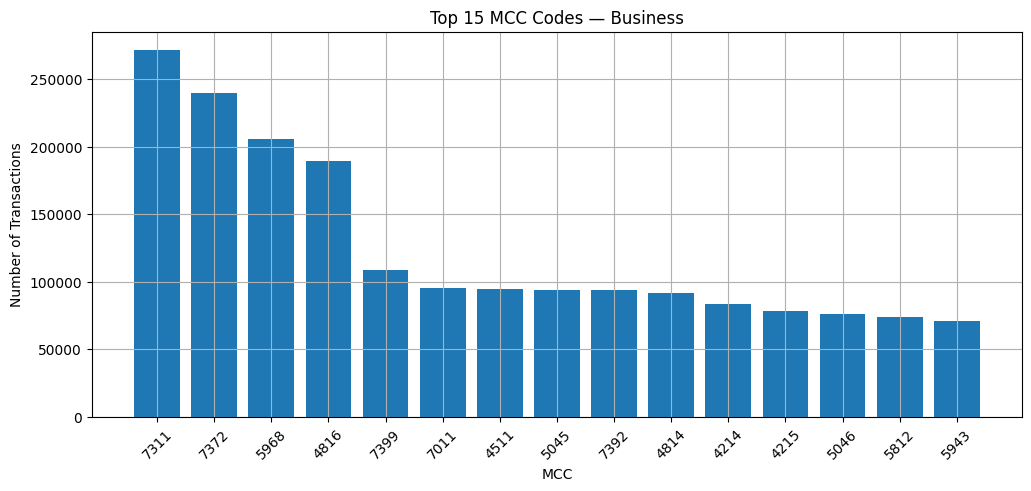

In [ ]:
top_mcc_business = data[data["target"] == 1]["mcc"].value_counts().head(15)

plt.figure(figsize=(12, 5))
plt.bar(top_mcc_business.index.astype(str), top_mcc_business.values)

plt.title("Top 15 MCC Codes — Business")
plt.xlabel("MCC")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.show()

In [ ]:
# consumer mcc
data[data["target"] == 0]["mcc"].value_counts().head(20)

mcc
4814    451480
5812    449438
4121    404310
5541    395086
4111    287214
7311    256115
5814    253705
4899    249966
5411    224191
5311    221550
5999    202094
5912    194054
7011    170723
5542    170271
5651    169442
4511    169406
5499    162351
5691    161097
5211    160430
5921    138080
Name: count, dtype: int64

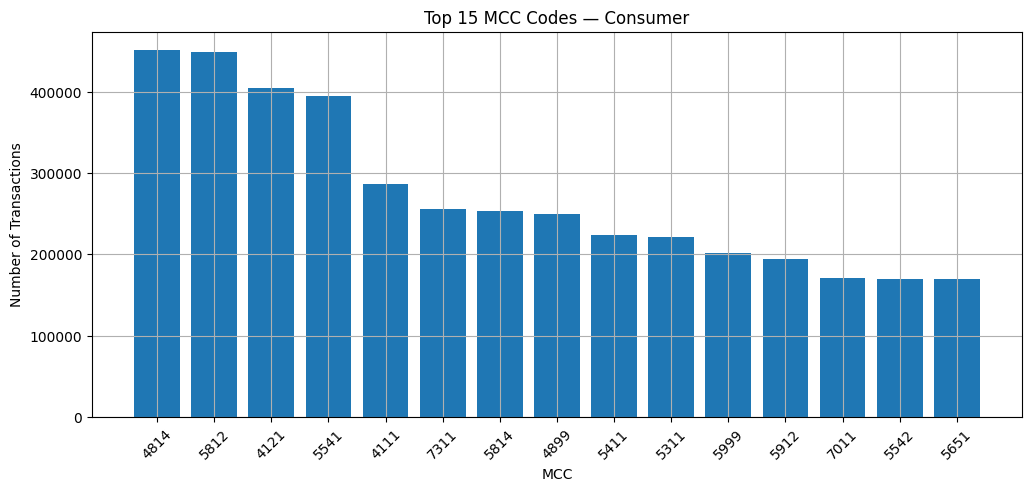

In [ ]:
top_mcc_consumer = data[data["target"] == 0]["mcc"].value_counts().head(15)

plt.figure(figsize=(12, 5))
plt.bar(top_mcc_consumer.index.astype(str), top_mcc_consumer.values)

plt.title("Top 15 MCC Codes — Consumer")
plt.xlabel("MCC")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.show()

MCC analysis helps identify which merchant categories dominate business and consumer behavior. Differences in MCC structure can later be used as important features for hidden SME detection.

In [ ]:
# checking recurring transactions
data.groupby("target")["is_recurring"].mean()

target
0    0.027180
1    0.133447
Name: is_recurring, dtype: float64

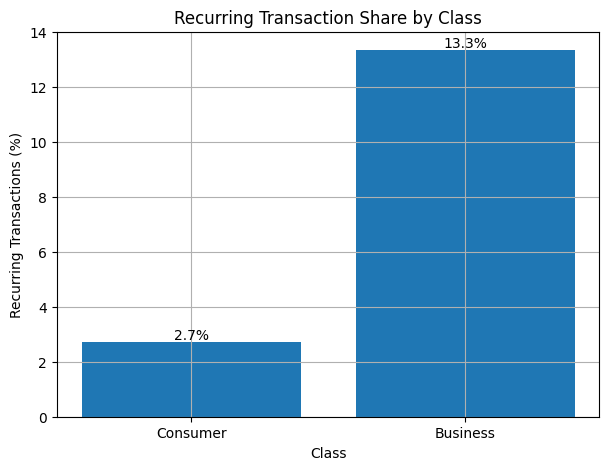

In [ ]:
recurring_share = data.groupby("target")["is_recurring"].mean() * 100

plt.figure(figsize=(7, 5))
plt.bar(["Consumer", "Business"], recurring_share.values)

plt.title("Recurring Transaction Share by Class")
plt.xlabel("Class")
plt.ylabel("Recurring Transactions (%)")

for i, value in enumerate(recurring_share.values):
    plt.text(i, value, f"{value:.1f}%", ha="center", va="bottom")

plt.show()

Recurring transactions may indicate subscriptions, automated payments, or regular business-related operations. This feature can be useful for identifying systematic commercial behavior.

In [ ]:
# checking online\channel transactions
data.groupby(["target", "channel"]).size()

target  channel
0       POS        5259386
        online     4573101
1       POS         459745
        online     2537848
dtype: int64

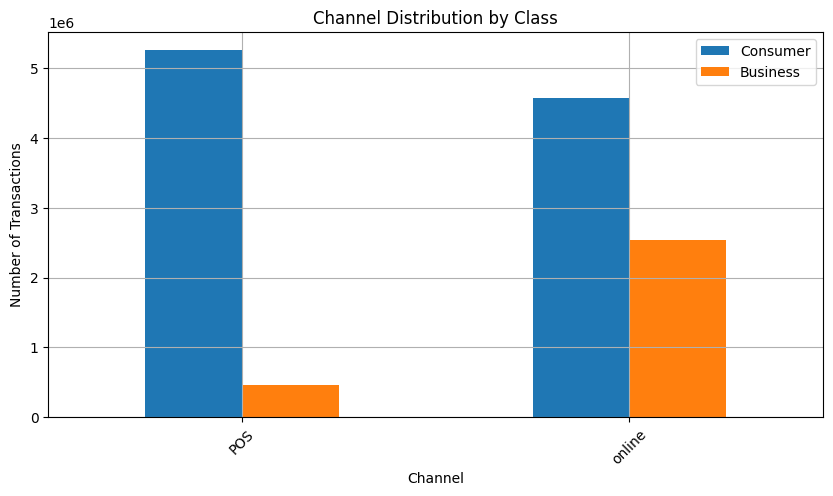

In [ ]:
channel_dist = (
    data.groupby(["target", "channel"])
    .size()
    .reset_index(name="count")
)

channel_pivot = channel_dist.pivot(
    index="channel",
    columns="target",
    values="count"
).fillna(0)

channel_pivot.columns = ["Consumer", "Business"]

channel_pivot.plot(kind="bar", figsize=(10, 5))

plt.title("Channel Distribution by Class")
plt.xlabel("Channel")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.show()

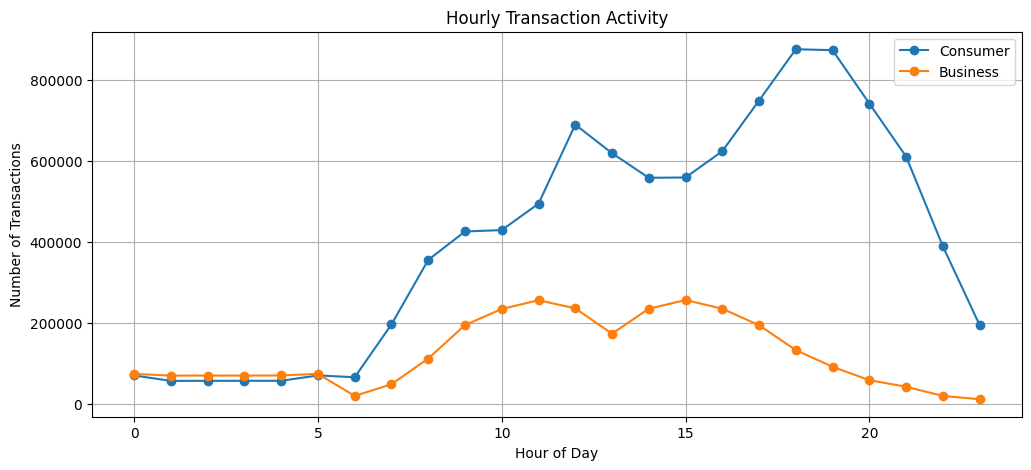

In [ ]:
# analyzing hourly activity
data["transaction_timestamp"] = pd.to_datetime(data["transaction_timestamp"])
data["hour"] = data["transaction_timestamp"].dt.hour

hourly_activity = data.groupby(["target", "hour"]).size().reset_index(name="count")

plt.figure(figsize=(12, 5))

for target, label in [(0, "Consumer"), (1, "Business")]:
    temp = hourly_activity[hourly_activity["target"] == target]
    plt.plot(temp["hour"], temp["count"], marker="o", label=label)

plt.title("Hourly Transaction Activity")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")
plt.legend()

plt.show()

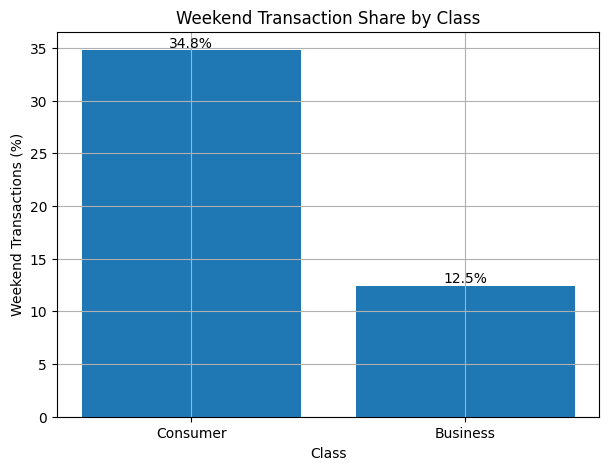

In [ ]:
# analyzing weekday vs weekend activity
data["weekday"] = data["transaction_timestamp"].dt.weekday
data["is_weekend"] = data["weekday"].isin([5, 6])

weekend_share = data.groupby("target")["is_weekend"].mean() * 100

plt.figure(figsize=(7, 5))
plt.bar(["Consumer", "Business"], weekend_share.values)

plt.title("Weekend Transaction Share by Class")
plt.xlabel("Class")
plt.ylabel("Weekend Transactions (%)")

for i, value in enumerate(weekend_share.values):
    plt.text(i, value, f"{value:.1f}%", ha="center", va="bottom")

plt.show()

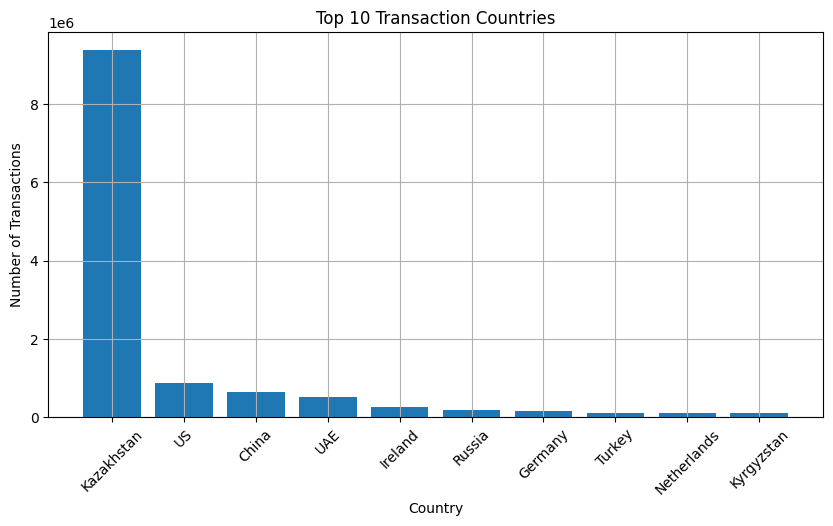

In [ ]:
# analyzing top countries
top_countries = data["country"].value_counts().head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_countries.index.astype(str), top_countries.values)

plt.title("Top 10 Transaction Countries")
plt.xlabel("Country")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.show()

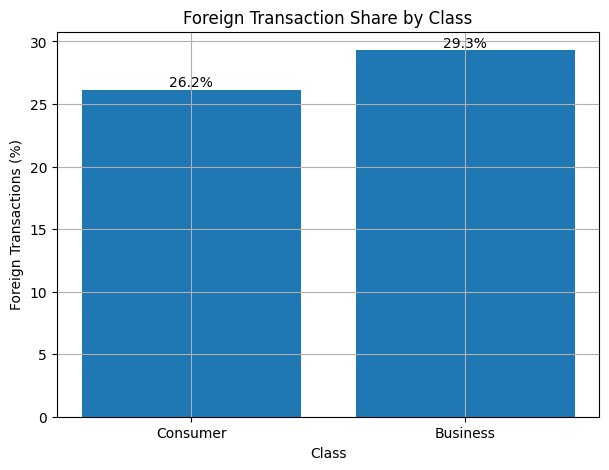

In [ ]:
# foreign transactions share

data["is_foreign"] = data["country"] != "Kazakhstan"

foreign_share = data.groupby("target")["is_foreign"].mean() * 100

plt.figure(figsize=(7, 5))
plt.bar(["Consumer", "Business"], foreign_share.values)

plt.title("Foreign Transaction Share by Class")
plt.xlabel("Class")
plt.ylabel("Foreign Transactions (%)")

for i, value in enumerate(foreign_share.values):
    plt.text(i, value, f"{value:.1f}%", ha="center", va="bottom")

plt.show()

In [ ]:
# сохраняем промежуточные результаты для дальнейшего анализа
data.to_parquet("combined_data.parquet", index=False)

#### **Preliminary Behavioral Patterns**

At the EDA stage, several preliminary behavioral differences between business and consumer transactions were identified.

Initial analysis revealed differences in:
- transaction amounts,
- turnover patterns,
- MCC category distribution,
- transaction frequency,
- recurring activity,
- and online/offline transaction behavior.

These observations provide early evidence that business-like activity demonstrates distinguishable behavioral characteristics compared to regular consumer behavior.

At this stage, the analysis is still performed on the transaction level. More advanced behavioral patterns will be extracted later during the aggregation and feature engineering stages, where transaction-level data will be transformed into card-level behavioral profiles.

## Data Preprocessing part

At this stage, the combined transaction dataset is prepared for card-level aggregation and machine learning.

The preprocessing flow follows the logic of future behavioral feature engineering:
- load the combined dataset,
- validate columns, data types, missing values, duplicates, and invalid amounts,
- process datetime features,
- validate the card-level aggregation key,
- define source columns for behavioral aggregation.

### Data Load

The combined dataset is loaded from the saved checkpoint created after the EDA stage.

At this point, we do not recreate the target variable or concatenate the original business and consumer datasets again, because these steps were already completed earlier.

The purpose of this step is to load the prepared combined dataset and verify that it is ready for preprocessing and card-level aggregation.

In [15]:
# Load the combined transaction dataset created after EDA

data = pd.read_parquet("combined_data.parquet")

print("Loaded data shape:", data.shape)
data.head()

Loaded data shape: (12830080, 22)


,transaction_date,transaction_timestamp,transaction_amount_kzt,mcc,merchant_id,channel,bank_name,country,card_number,card_tier,...,target,merchant_name,mcc_merchant,merchant_country,recurring_capable,log_amount,hour,weekday,is_weekend,is_foreign
0,2025-10-01,2025-10-01 00:00:00,180976,7372,MER_000007,online,Kaspi,US,5228592291438845,Business,...,1,Microsoft Azure,7372,US,True,12.106125,0,2,False,True
1,2025-10-01,2025-10-01 00:00:00,153206,7372,MER_000006,online,Home Credit Bank,US,5201495142193372,Business,...,1,Amazon Web Services,7372,US,True,11.939545,0,2,False,True
2,2025-10-01,2025-10-01 00:00:00,197106,7372,MER_000007,online,Home Credit Bank,US,5201492177677288,Business,...,1,Microsoft Azure,7372,US,True,12.191502,0,2,False,True
3,2025-10-01,2025-10-01 00:01:00,189598,7372,MER_000008,online,Kaspi,US,5176513443697635,Business,...,1,Google Cloud,7372,US,True,12.152667,0,2,False,True
4,2025-10-01,2025-10-01 00:03:00,700571,7311,MER_000003,online,Halyk,Russia,5100611967455520,Business,...,1,Yandex Direct,7311,Russia,True,13.459652,0,2,False,True


### Columns and Data Types Check

Before cleaning and aggregation, we check the available columns and their data types.

This step helps confirm that the combined dataset contains the fields needed for transaction amount behavior, merchant behavior, digital/payment behavior, temporal behavior, and the target label.

In [16]:
# Check available columns

data.columns.tolist()

['transaction_date',
 'transaction_timestamp',
 'transaction_amount_kzt',
 'mcc',
 'merchant_id',
 'channel',
 'bank_name',
 'country',
 'card_number',
 'card_tier',
 'tokenized',
 'is_recurring',
 'target',
 'merchant_name',
 'mcc_merchant',
 'merchant_country',
 'recurring_capable',
 'log_amount',
 'hour',
 'weekday',
 'is_weekend',
 'is_foreign']

In [17]:
# Check data types and memory usage

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12830080 entries, 0 to 12830079
Data columns (total 22 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   transaction_date        object        
 1   transaction_timestamp   datetime64[ms]
 2   transaction_amount_kzt  int64         
 3   mcc                     object        
 4   merchant_id             object        
 5   channel                 object        
 6   bank_name               object        
 7   country                 object        
 8   card_number             object        
 9   card_tier               object        
 10  tokenized               bool          
 11  is_recurring            bool          
 12  target                  int64         
 13  merchant_name           object        
 14  mcc_merchant            object        
 15  merchant_country        object        
 16  recurring_capable       bool          
 17  log_amount              float64       
 18  

### Missing Values Check

Missing values are checked before aggregation because nulls can distort card-level behavioral features.

For example, missing merchant or MCC values may affect merchant diversity, while missing channel or recurring flags may affect digital/payment behavior features.

In [18]:
# Check missing values by column

missing_values = data.isna().sum().sort_values(ascending=False)
missing_values.head(20)

transaction_date          0
transaction_timestamp     0
transaction_amount_kzt    0
mcc                       0
merchant_id               0
channel                   0
bank_name                 0
country                   0
card_number               0
card_tier                 0
tokenized                 0
is_recurring              0
target                    0
merchant_name             0
mcc_merchant              0
merchant_country          0
recurring_capable         0
log_amount                0
hour                      0
weekday                   0
dtype: int64

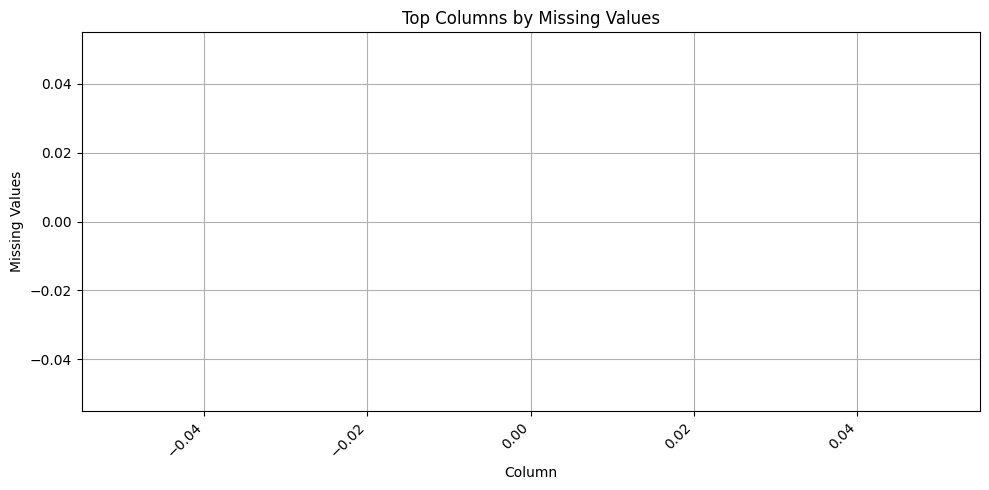

In [19]:
# Visualize columns with the largest number of missing values

missing_values_to_plot = missing_values[missing_values > 0].head(20)

plt.figure(figsize=(10, 5))
plt.bar(missing_values_to_plot.index, missing_values_to_plot.values)
plt.title("Top Columns by Missing Values")
plt.xlabel("Column")
plt.ylabel("Missing Values")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Duplicate Transaction Check

Duplicate transactions are checked using the available transaction-identifying columns.

This is important because duplicated rows can inflate transaction count, turnover, merchant concentration, and other behavioral aggregation features.

In [20]:
# Check duplicates using transaction-identifying columns that exist in the dataset

possible_key_cols = [
    "card_number",
    "merchant_id",
    "transaction_amount_kzt",
    "transaction_timestamp",
    "transaction_date"
]

existing_key_cols = [col for col in possible_key_cols if col in data.columns]

duplicate_count = data.duplicated(subset=existing_key_cols).sum()

print("Duplicate check columns:", existing_key_cols)
print("Duplicate rows:", duplicate_count)

Duplicate check columns: ['card_number', 'merchant_id', 'transaction_amount_kzt', 'transaction_timestamp', 'transaction_date']
Duplicate rows: 0


### Invalid Amount Check

Transaction amounts are validated before aggregation because zero or negative amounts can distort turnover, average amount, median amount, maximum amount, and spending variability features.

In [21]:
# Check basic transaction amount statistics

data["transaction_amount_kzt"].describe()

count    1.283008e+07
mean     7.799094e+04
std      1.971753e+05
min      1.500000e+01
25%      5.028000e+03
50%      1.743100e+04
75%      6.875400e+04
max      4.079930e+07
Name: transaction_amount_kzt, dtype: float64

In [22]:
# Check zero or negative transaction amounts

invalid_amount_mask = data["transaction_amount_kzt"] <= 0
invalid_amounts = invalid_amount_mask.sum()
valid_amounts = (~invalid_amount_mask).sum()

print("Amount <= 0:", invalid_amounts)
print("Amount > 0:", valid_amounts)

Amount <= 0: 0
Amount > 0: 12830080


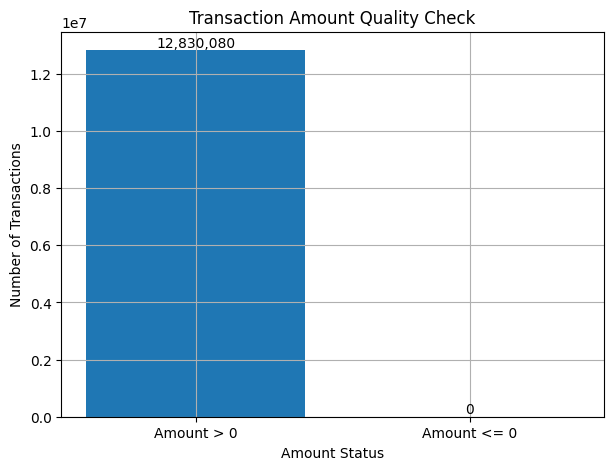

In [23]:
# Visualize valid vs invalid transaction amount records

amount_quality_counts = pd.Series({
    "Amount > 0": valid_amounts,
    "Amount <= 0": invalid_amounts
})

plt.figure(figsize=(7, 5))
plt.bar(amount_quality_counts.index, amount_quality_counts.values)
plt.title("Transaction Amount Quality Check")
plt.xlabel("Amount Status")
plt.ylabel("Number of Transactions")

for i, value in enumerate(amount_quality_counts.values):
    plt.text(i, value, f"{value:,}", ha="center", va="bottom")

plt.show()

### Datetime Processing

Datetime variables are processed to extract time-based behavioral source columns.

The raw transaction date/time column is converted into aggregation-ready features such as hour, weekday, weekend flag, business-hours flag, and cleaned transaction date. These columns will later help measure when card activity happens and how regular it is.

In [24]:
# Find columns related to date or time

date_cols = [col for col in data.columns if "date" in col.lower() or "time" in col.lower()]

date_cols

['transaction_date', 'transaction_timestamp']

In [25]:
# Select the main datetime column for temporal feature extraction

if "transaction_timestamp" in data.columns:
    datetime_col = "transaction_timestamp"
elif "transaction_date" in data.columns:
    datetime_col = "transaction_date"
else:
    datetime_col = date_cols[0]

datetime_col

'transaction_timestamp'

In [26]:
# Convert the selected datetime column to datetime format

data[datetime_col] = pd.to_datetime(
    data[datetime_col],
    errors="coerce"
)

In [27]:
# Create temporal source columns for future behavioral aggregation

data["hour"] = data[datetime_col].dt.hour
data["weekday"] = data[datetime_col].dt.weekday
data["is_weekend"] = data["weekday"].isin([5, 6]).astype("int8")
data["is_business_hours"] = data["hour"].between(9, 18).astype("int8")
data["transaction_date_clean"] = data[datetime_col].dt.date

data[["hour", "weekday", "is_weekend", "is_business_hours", "transaction_date_clean"]].head()

,hour,weekday,is_weekend,is_business_hours,transaction_date_clean
0,0,2,0,0,2025-10-01
1,0,2,0,0,2025-10-01
2,0,2,0,0,2025-10-01
3,0,2,0,0,2025-10-01
4,0,2,0,0,2025-10-01


In [28]:
# Check how many datetime values could not be parsed

data[datetime_col].isna().sum()

np.int64(0)

### Card Number Check

`card_number` is the key for converting transaction-level data into card-level behavioral profiles.

Rows without `card_number` cannot be aggregated correctly, so this identifier must be validated before selecting behavioral source columns.

In [29]:
# Check missing card_number values

data["card_number"].isna().sum()

np.int64(0)

In [30]:
# Check the number of unique cards

data["card_number"].nunique()

105000

In [31]:
# Drop rows without card_number because card-level aggregation is impossible without this key

data = data.dropna(subset=["card_number"])

print("Shape after card_number cleaning:", data.shape)

Shape after card_number cleaning: (12830080, 24)


### Model Feature Source Columns

The following columns are selected not randomly, but because they are the source data needed to construct future model features.

Each group corresponds to a part of cardholder behavior that will later be aggregated from transaction level to card level.

In [32]:
behavioral_source_cols = {
    "Identification / Target": [
        "card_number",
        "target"
    ],
    "Transaction Behavior": [
        "transaction_amount_kzt"
    ],
    "Merchant Behavior": [
        "merchant_id",
        "mcc",
        "country"
    ],
    "Digital / Payment Behavior": [
        "channel",
        "is_recurring"
    ],
    "Temporal Behavior": [
        "hour",
        "weekday",
        "is_weekend",
        "is_business_hours",
        "transaction_date_clean"
    ]
}

rows = []

column_purpose = {
    "card_number": "Key for aggregating transactions into one card-level profile",
    "target": "Class label: 1 = business behavior, 0 = consumer behavior",
    "transaction_amount_kzt": "Used to calculate turnover, average amount, median amount, maximum amount and spending variability",
    "merchant_id": "Used to calculate merchant diversity and merchant concentration",
    "mcc": "Used to analyze merchant category behavior and MCC diversity",
    "country": "Used to identify domestic vs foreign transaction behavior",
    "channel": "Used to analyze online/offline or channel-based transaction behavior",
    "is_recurring": "Used to calculate recurring transaction share",
    "hour": "Used to analyze hourly transaction activity",
    "weekday": "Used to analyze weekly activity patterns",
    "is_weekend": "Used to calculate weekend transaction share",
    "is_business_hours": "Used to calculate business-hours activity share",
    "transaction_date_clean": "Used to calculate active days and transaction regularity"
}

for group_name, columns in behavioral_source_cols.items():
    for col in columns:
        rows.append({
            "Feature Group": group_name,
            "Column": col,
            "Purpose for Aggregation": column_purpose[col],
            "Exists in Dataset": col in data.columns
        })

behavioral_source_table = pd.DataFrame(rows)

behavioral_source_table

,Feature Group,Column,Purpose for Aggregation,Exists in Dataset
0,Identification / Target,card_number,Key for aggregating transactions into one card...,True
1,Identification / Target,target,"Class label: 1 = business behavior, 0 = consum...",True
2,Transaction Behavior,transaction_amount_kzt,"Used to calculate turnover, average amount, me...",True
3,Merchant Behavior,merchant_id,Used to calculate merchant diversity and merch...,True
4,Merchant Behavior,mcc,Used to analyze merchant category behavior and...,True
5,Merchant Behavior,country,Used to identify domestic vs foreign transacti...,True
6,Digital / Payment Behavior,channel,Used to analyze online/offline or channel-base...,True
7,Digital / Payment Behavior,is_recurring,Used to calculate recurring transaction share,True
8,Temporal Behavior,hour,Used to analyze hourly transaction activity,True
9,Temporal Behavior,weekday,Used to analyze weekly activity patterns,True


In [33]:
# Keep only existing behavioral source columns for future aggregation

behavioral_source_flat_cols = [
    col
    for columns in behavioral_source_cols.values()
    for col in columns
]

existing_behavioral_source_cols = [
    col for col in behavioral_source_flat_cols
    if col in data.columns
]

missing_behavioral_source_cols = [
    col for col in behavioral_source_flat_cols
    if col not in data.columns
]

print("Existing behavioral source columns:")
print(existing_behavioral_source_cols)

print("Missing behavioral source columns:")
print(missing_behavioral_source_cols)

Existing behavioral source columns:
['card_number', 'target', 'transaction_amount_kzt', 'merchant_id', 'mcc', 'country', 'channel', 'is_recurring', 'hour', 'weekday', 'is_weekend', 'is_business_hours', 'transaction_date_clean']
Missing behavioral source columns:
[]


In [34]:
# Prepare transaction-level source data for card-level behavioral aggregation

data_preprocessed = data[existing_behavioral_source_cols].copy()

print("Preprocessed data shape:", data_preprocessed.shape)
data_preprocessed.head()

Preprocessed data shape: (12830080, 13)


,card_number,target,transaction_amount_kzt,merchant_id,mcc,country,channel,is_recurring,hour,weekday,is_weekend,is_business_hours,transaction_date_clean
0,5228592291438845,1,180976,MER_000007,7372,US,online,True,0,2,0,0,2025-10-01
1,5201495142193372,1,153206,MER_000006,7372,US,online,True,0,2,0,0,2025-10-01
2,5201492177677288,1,197106,MER_000007,7372,US,online,True,0,2,0,0,2025-10-01
3,5176513443697635,1,189598,MER_000008,7372,US,online,True,0,2,0,0,2025-10-01
4,5100611967455520,1,700571,MER_000003,7311,Russia,online,True,0,2,0,0,2025-10-01


### Preparing Data for Model Features

The dataset was prepared as transaction-level source data for card-level model feature engineering.

The next stage will transform the data from:

`1 row = 1 transaction`

to:

`1 row = 1 card`

In [35]:
# Short class balance check after preprocessing

class_balance = pd.DataFrame({
    "transactions": data_preprocessed["target"].value_counts().sort_index(),
    "share_percent": data_preprocessed["target"].value_counts(normalize=True).sort_index() * 100
})

class_balance

,transactions,share_percent
target,,
0,9832487,76.63621
1,2997593,23.36379


### Class Balance Check

Class balance was checked briefly at the transaction level after preprocessing.

The final balance for modeling will be checked again after aggregation by `card_number`.

In [36]:
# Save the preprocessed source dataset as a checkpoint

data_preprocessed.to_parquet(
    "preprocessed_transactions.parquet",
    index=False,
    compression="snappy"
)

### Preprocessing Checkpoint

The preprocessed transaction dataset was saved as a checkpoint.

This allows continuing with aggregation and feature engineering without rerunning all previous preprocessing steps.

### Data Preprocessing Summary

During preprocessing, the transaction-level dataset was validated and prepared as source data for card-level behavioral aggregation.

Completed steps:
- combined dataset was loaded from checkpoint,
- columns and data types were checked,
- missing values were checked and visualized,
- duplicate transactions were checked,
- invalid transaction amounts were validated and visualized,
- datetime features were created,
- `card_number` was validated as the aggregation key,
- model feature source columns were defined with clear aggregation purposes,
- class balance was briefly reviewed.

The dataset is now ready for aggregation by `card_number`, where each card will be transformed into a behavioral profile.

## Aggregation & Feature Engineering part

At this stage, the preprocessed transaction-level dataset is transformed into a card-level feature dataset.

The goal is to create one row per card, where each row represents the overall behavioral profile of the cardholder.

These engineered features will later be used for machine learning model training.

In [44]:
# loading the last updated dataset
data_preprocessed = pd.read_parquet("preprocessed_transactions.parquet")
data_preprocessed.head()

,card_number,target,transaction_amount_kzt,merchant_id,mcc,country,channel,is_recurring,hour,weekday,is_weekend,is_business_hours,transaction_date_clean
0,5228592291438845,1,180976,MER_000007,7372,US,online,True,0,2,0,0,2025-10-01
1,5201495142193372,1,153206,MER_000006,7372,US,online,True,0,2,0,0,2025-10-01
2,5201492177677288,1,197106,MER_000007,7372,US,online,True,0,2,0,0,2025-10-01
3,5176513443697635,1,189598,MER_000008,7372,US,online,True,0,2,0,0,2025-10-01
4,5100611967455520,1,700571,MER_000003,7311,Russia,online,True,0,2,0,0,2025-10-01


### Transaction Features

Transaction features describe the general financial activity of each cardholder, including transaction frequency, total turnover, average transaction amount, and spending variability.

In [39]:
# Creating transaction features 
transaction_features = data.groupby("card_number").agg(
    target=("target", "max"),
    tx_count=("transaction_amount_kzt", "count"),
    total_turnover=("transaction_amount_kzt", "sum"),
    avg_amount=("transaction_amount_kzt", "mean"),
    median_amount=("transaction_amount_kzt", "median"),
    max_amount=("transaction_amount_kzt", "max"),
    std_amount=("transaction_amount_kzt", "std")
).reset_index()

transaction_features["std_amount"] = (
    transaction_features["std_amount"].fillna(0)
)

transaction_features.head()

,card_number,target,tx_count,total_turnover,avg_amount,median_amount,max_amount,std_amount
0,5100610003025081,1,178,9651486,54221.831461,14499.0,745914,92378.778008
1,5100610003044611,1,106,14353608,135411.396226,67810.0,1483178,198947.026012
2,5100610003860784,1,148,13102356,88529.432432,56445.0,652796,101798.906783
3,5100610005930965,0,43,14215001,330581.418605,168999.0,2137325,457017.109755
4,5100610005962109,0,119,1303168,10950.991597,5886.0,223504,23120.959998


### Merchant Features

Merchant features capture how diverse the cardholder's activity is across merchants, MCC categories, and countries. These features help identify whether a client interacts with many different merchants or has a more concentrated transaction pattern.

In [45]:
merchant_features = data_preprocessed.groupby("card_number").agg(
    unique_merchants=("merchant_id", "nunique"),
    unique_mcc=("mcc", "nunique"),
    unique_countries=("country", "nunique")
).reset_index()

merchant_features.head()

,card_number,unique_merchants,unique_mcc,unique_countries
0,5100610003025081,9,9,9
1,5100610003044611,18,18,5
2,5100610003860784,8,8,3
3,5100610005930965,7,7,4
4,5100610005962109,46,43,9


### Behavioral Features

Behavioral features describe recurring, weekend, and business-hour activity. These indicators help capture regularity and timing patterns that may be associated with business-like behavior.

In [46]:
behavioral_features = data_preprocessed.groupby("card_number").agg(
    recurring_share=("is_recurring", "mean"),
    weekend_share=("is_weekend", "mean"),
    business_hours_share=("is_business_hours", "mean")
).reset_index()

behavioral_features.head()

,card_number,recurring_share,weekend_share,business_hours_share
0,5100610003025081,0.067416,0.101124,0.758427
1,5100610003044611,0.169811,0.122642,0.698113
2,5100610003860784,0.040541,0.114865,0.844595
3,5100610005930965,0.418605,0.232558,0.465116
4,5100610005962109,0.050420,0.302521,0.588235


### Time-Based Features

Time-based features describe how regularly and when each card is active. Active days and average transaction hour help capture temporal behavior patterns at the card level.

In [47]:
time_features = data_preprocessed.groupby("card_number").agg(
    active_days=("transaction_date_clean", "nunique"),
    avg_hour=("hour", "mean"),
    std_hour=("hour", "std")
).reset_index()

time_features["std_hour"] = time_features["std_hour"].fillna(0)

time_features.head()

,card_number,active_days,avg_hour,std_hour
0,5100610003025081,105,12.617978,4.758592
1,5100610003044611,80,11.933962,5.620149
2,5100610003860784,90,12.966216,3.983667
3,5100610005930965,40,9.488372,6.663233
4,5100610005962109,82,14.016807,5.523422


### Merchant Concentration Features

Merchant concentration measures how much of a card's turnover is concentrated in one or several merchants.

A high top merchant share may indicate repeated interaction with the same supplier, platform, or business-related merchant, which can be useful for hidden SME detection.

In [48]:
merchant_amount = (
    data_preprocessed
    .groupby(["card_number", "merchant_id"])["transaction_amount_kzt"]
    .sum()
    .reset_index()
)

merchant_total = (
    data_preprocessed
    .groupby("card_number")["transaction_amount_kzt"]
    .sum()
    .reset_index()
    .rename(columns={"transaction_amount_kzt": "total_turnover"})
)

merchant_amount = merchant_amount.merge(
    merchant_total,
    on="card_number",
    how="left"
)

merchant_amount["merchant_share"] = (
    merchant_amount["transaction_amount_kzt"] / merchant_amount["total_turnover"]
)

merchant_concentration = (
    merchant_amount
    .groupby("card_number")
    .agg(
        top_merchant_share=("merchant_share", "max"),
        merchant_hhi=("merchant_share", lambda x: np.sum(x ** 2))
    )
    .reset_index()
)

merchant_concentration.head()

,card_number,top_merchant_share,merchant_hhi
0,5100610003025081,0.252958,0.189605
1,5100610003044611,0.271315,0.152446
2,5100610003860784,0.337584,0.218715
3,5100610005930965,0.800573,0.652188
4,5100610005962109,0.171508,0.080147


### MCC Concentration Features

MCC concentration measures how concentrated a card's turnover is across merchant categories. This helps detect whether the cardholder has focused commercial activity in specific business-related categories.

In [49]:
mcc_amount = (
    data_preprocessed
    .groupby(["card_number", "mcc"])["transaction_amount_kzt"]
    .sum()
    .reset_index()
)

mcc_total = (
    data_preprocessed
    .groupby("card_number")["transaction_amount_kzt"]
    .sum()
    .reset_index()
    .rename(columns={"transaction_amount_kzt": "total_turnover"})
)

mcc_amount = mcc_amount.merge(
    mcc_total,
    on="card_number",
    how="left"
)

mcc_amount["mcc_share"] = (
    mcc_amount["transaction_amount_kzt"] / mcc_amount["total_turnover"]
)

mcc_concentration = (
    mcc_amount
    .groupby("card_number")
    .agg(
        top_mcc_share=("mcc_share", "max"),
        mcc_hhi=("mcc_share", lambda x: np.sum(x ** 2))
    )
    .reset_index()
)

mcc_concentration.head()

,card_number,top_mcc_share,mcc_hhi
0,5100610003025081,0.252958,0.189605
1,5100610003044611,0.271315,0.152446
2,5100610003860784,0.337584,0.218715
3,5100610005930965,0.800573,0.652188
4,5100610005962109,0.171508,0.080603


### Final Card-Level Feature Dataset

All engineered feature tables are merged into one final card-level dataset using `card_number` as the key.

The final dataset contains one row per card and will be used for machine learning model training.

In [50]:
features = transaction_features.copy()

feature_tables = [
    merchant_features,
    behavioral_features,
    time_features,
    merchant_concentration,
    mcc_concentration
]

for table in feature_tables:
    features = features.merge(
        table,
        on="card_number",
        how="left"
    )

features = features.fillna(0)

features.head()

,card_number,target,tx_count,total_turnover,avg_amount,median_amount,max_amount,std_amount,unique_merchants,unique_mcc,...,recurring_share,weekend_share,business_hours_share,active_days,avg_hour,std_hour,top_merchant_share,merchant_hhi,top_mcc_share,mcc_hhi
0,5100610003025081,1,178,9651486,54221.831461,14499.0,745914,92378.778008,9,9,...,0.067416,0.101124,0.758427,105,12.617978,4.758592,0.252958,0.189605,0.252958,0.189605
1,5100610003044611,1,106,14353608,135411.396226,67810.0,1483178,198947.026012,18,18,...,0.169811,0.122642,0.698113,80,11.933962,5.620149,0.271315,0.152446,0.271315,0.152446
2,5100610003860784,1,148,13102356,88529.432432,56445.0,652796,101798.906783,8,8,...,0.040541,0.114865,0.844595,90,12.966216,3.983667,0.337584,0.218715,0.337584,0.218715
3,5100610005930965,0,43,14215001,330581.418605,168999.0,2137325,457017.109755,7,7,...,0.418605,0.232558,0.465116,40,9.488372,6.663233,0.800573,0.652188,0.800573,0.652188
4,5100610005962109,0,119,1303168,10950.991597,5886.0,223504,23120.959998,46,43,...,0.050420,0.302521,0.588235,82,14.016807,5.523422,0.171508,0.080147,0.171508,0.080603


### Ratio Features

Ratio features normalize transaction behavior by activity level. They help compare cards with different numbers of transactions and active days more fairly.

In [51]:
features["avg_tx_per_active_day"] = (
    features["tx_count"] / features["active_days"].replace(0, np.nan)
)

features["turnover_per_active_day"] = (
    features["total_turnover"] / features["active_days"].replace(0, np.nan)
)

features["merchant_per_tx_ratio"] = (
    features["unique_merchants"] / features["tx_count"].replace(0, np.nan)
)

features["mcc_per_tx_ratio"] = (
    features["unique_mcc"] / features["tx_count"].replace(0, np.nan)
)

features = features.fillna(0)

features.head()

,card_number,target,tx_count,total_turnover,avg_amount,median_amount,max_amount,std_amount,unique_merchants,unique_mcc,...,avg_hour,std_hour,top_merchant_share,merchant_hhi,top_mcc_share,mcc_hhi,avg_tx_per_active_day,turnover_per_active_day,merchant_per_tx_ratio,mcc_per_tx_ratio
0,5100610003025081,1,178,9651486,54221.831461,14499.0,745914,92378.778008,9,9,...,12.617978,4.758592,0.252958,0.189605,0.252958,0.189605,1.695238,91918.914286,0.050562,0.050562
1,5100610003044611,1,106,14353608,135411.396226,67810.0,1483178,198947.026012,18,18,...,11.933962,5.620149,0.271315,0.152446,0.271315,0.152446,1.325000,179420.100000,0.169811,0.169811
2,5100610003860784,1,148,13102356,88529.432432,56445.0,652796,101798.906783,8,8,...,12.966216,3.983667,0.337584,0.218715,0.337584,0.218715,1.644444,145581.733333,0.054054,0.054054
3,5100610005930965,0,43,14215001,330581.418605,168999.0,2137325,457017.109755,7,7,...,9.488372,6.663233,0.800573,0.652188,0.800573,0.652188,1.075000,355375.025000,0.162791,0.162791
4,5100610005962109,0,119,1303168,10950.991597,5886.0,223504,23120.959998,46,43,...,14.016807,5.523422,0.171508,0.080147,0.171508,0.080603,1.451220,15892.292683,0.386555,0.361345


### Correlation Analysis

Correlation analysis is performed to understand relationships between engineered features and identify highly correlated variables before model training.

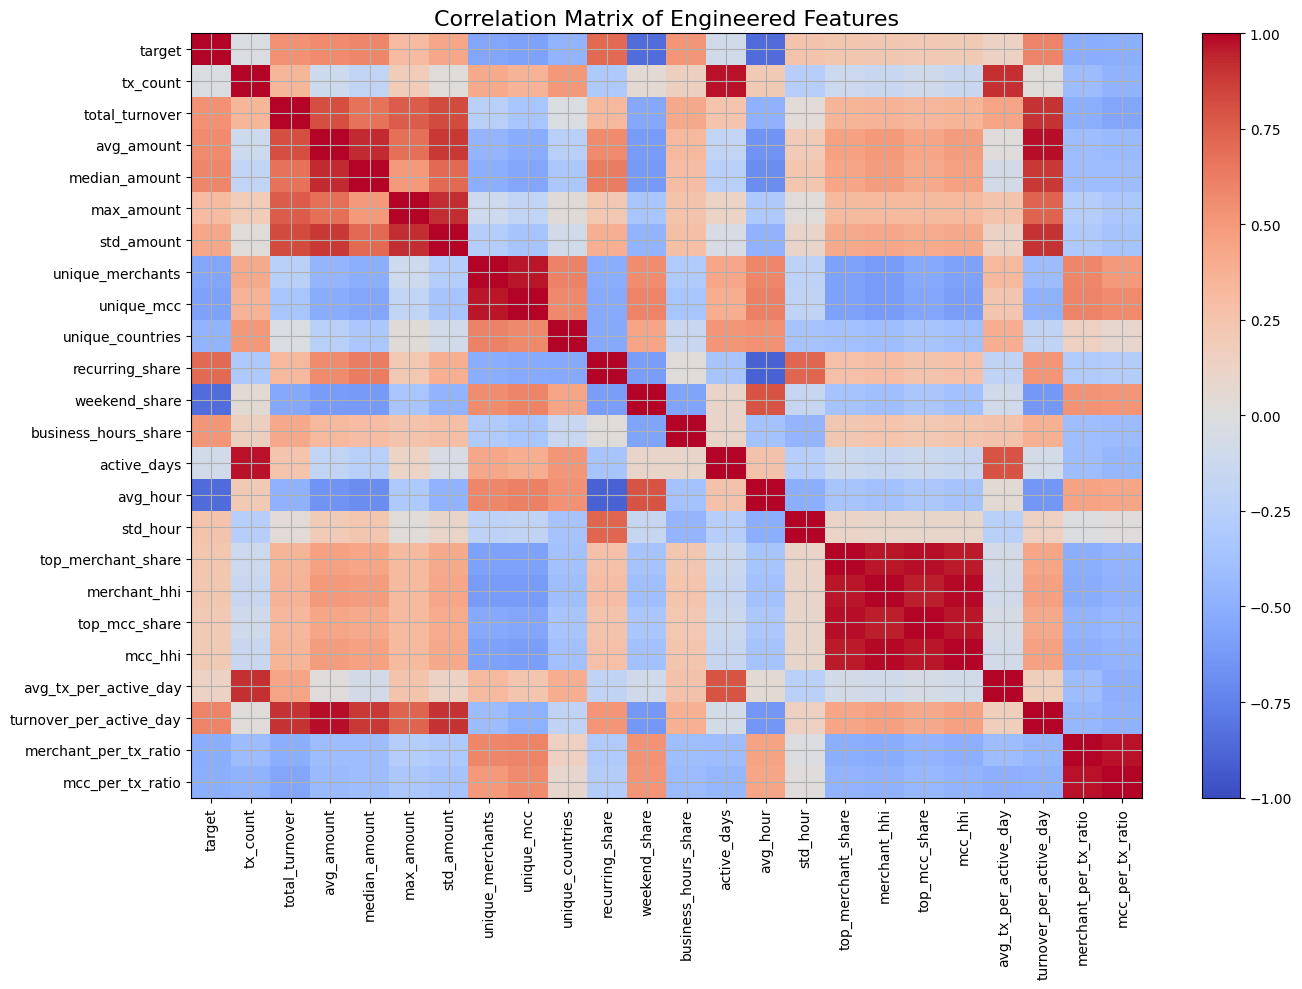

In [53]:
corr = numeric_features.corr()

plt.figure(figsize=(14, 10))

im = plt.imshow(
    corr,
    aspect="auto",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(im)

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title(
    "Correlation Matrix of Engineered Features",
    fontsize=16
)

plt.tight_layout()

plt.show()

Strong positive correlations are observed between transaction activity and turnover-related features, which is expected since highly active cards usually demonstrate larger transaction volumes and higher spending.

Merchant concentration and diversity features also show clear behavioral patterns, indicating that merchant interaction may be an important signal for hidden SME detection.

Overall, the analysis confirms that the engineered features capture multiple dimensions of client behavior, including financial activity, merchant behavior, concentration, and temporal transaction patterns.

### Saving Final ML Dataset

The final card-level feature dataset is saved as a checkpoint. This dataset will be used in the next stage for model training and hidden SME detection.

In [54]:
features.to_parquet(
    "final_card_level_features.parquet",
    index=False,
    compression="snappy"
)

### ML Modeling Preparation

At this stage, the final card-level behavioral dataset is prepared for machine learning modeling.

The objective is to train a predictive model capable of distinguishing business-like transaction behavior from regular consumer behavior using engineered behavioral features.

### Target Distribution

Before model training, the target distribution is checked to ensure that both classes are represented correctly in the final aggregated dataset.

In [ ]:
features["target"].value_counts()


target
0    80000
1    25000
Name: count, dtype: int64

In [56]:
features["target"].value_counts(normalize=True) * 100

target
0    76.190476
1    23.809524
Name: proportion, dtype: float64

### Feature Matrix and Target Variable

The dataset is split into:
- `X` → engineered behavioral features,
- `y` → target variable representing transaction behavior class.

In [57]:
X = features.drop(columns=["card_number", "target"])
y = features["target"]

print(X.shape)
print(y.shape)

(105000, 23)
(105000,)


### Feature Overview

The final feature set contains transaction, merchant, behavioral, temporal, and concentration-based indicators engineered during the aggregation stage.

In [58]:
X.columns.tolist()

['tx_count',
 'total_turnover',
 'avg_amount',
 'median_amount',
 'max_amount',
 'std_amount',
 'unique_merchants',
 'unique_mcc',
 'unique_countries',
 'recurring_share',
 'weekend_share',
 'business_hours_share',
 'active_days',
 'avg_hour',
 'std_hour',
 'top_merchant_share',
 'merchant_hhi',
 'top_mcc_share',
 'mcc_hhi',
 'avg_tx_per_active_day',
 'turnover_per_active_day',
 'merchant_per_tx_ratio',
 'mcc_per_tx_ratio']

### Missing Value Validation

A final validation step is performed to ensure that the feature matrix does not contain missing values before model training.

In [59]:
X.isna().sum().sort_values(ascending=False).head(20)

tx_count                 0
total_turnover           0
avg_amount               0
median_amount            0
max_amount               0
std_amount               0
unique_merchants         0
unique_mcc               0
unique_countries         0
recurring_share          0
weekend_share            0
business_hours_share     0
active_days              0
avg_hour                 0
std_hour                 0
top_merchant_share       0
merchant_hhi             0
top_mcc_share            0
mcc_hhi                  0
avg_tx_per_active_day    0
dtype: int64

### Train-Test Split

The dataset is divided into training and testing subsets.

A stratified split is used to preserve the original class distribution in both subsets.

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (84000, 23)
Test shape: (21000, 23)


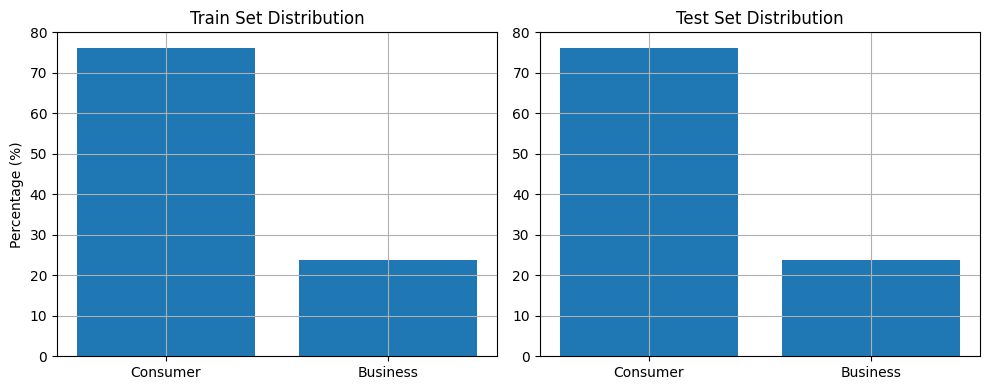

In [61]:
train_balance = y_train.value_counts(normalize=True) * 100
test_balance = y_test.value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(["Consumer", "Business"], train_balance.sort_index().values)
axes[0].set_title("Train Set Distribution")
axes[0].set_ylabel("Percentage (%)")

axes[1].bar(["Consumer", "Business"], test_balance.sort_index().values)
axes[1].set_title("Test Set Distribution")

plt.tight_layout()
plt.show()

### Feature Scaling Consideration

Tree-based models such as LightGBM and CatBoost do not require feature scaling. Therefore, the original feature values are preserved for the baseline supervised models.

Scaling may be considered later for distance-based or anomaly-detection algorithms.